In [1]:
import os 
import ot
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch import optim
import logging
import gmm
import RFmodules as rf
from torch.utils.tensorboard import SummaryWriter
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
print("Using device:", device)

Using device: cpu


Generated 3-mixture of Gaussians with 1000 samples.
KNN clustering accuracy: 100.00%
Cluster Proportions:
Cluster 1: 33.33%
Cluster 2: 33.33%
Cluster 0: 33.33%


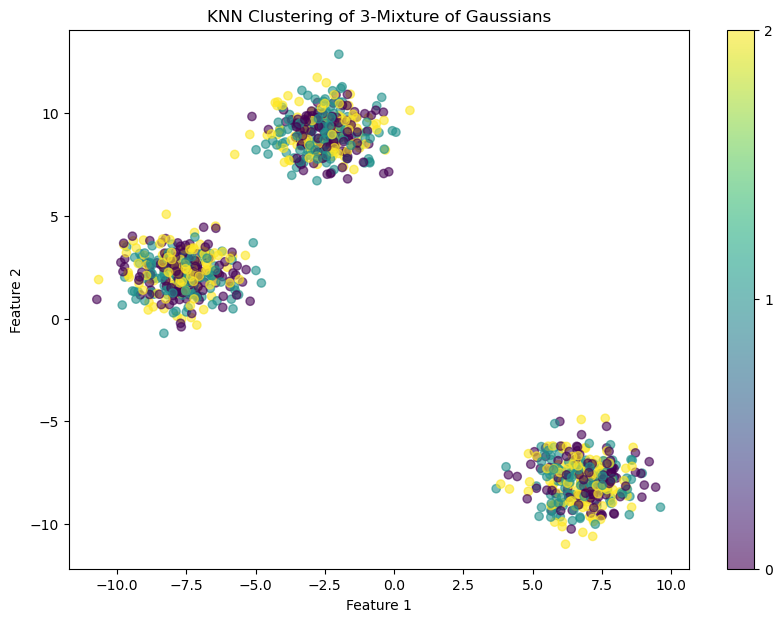

In [3]:
#Usage example:
N_CLUSTERS = 3
CENTERS = None
MIXTURE_PROBS = None

gmm_knn = gmm.GaussianMixtureKNN(n_clusters= N_CLUSTERS, n_samples=1000, n_features=2,
                                 centers=CENTERS, mixture_probs=MIXTURE_PROBS)
gmm_knn.create_mixture()
gmm_knn.perform_knn(n_neighbors=5)
gmm_knn.calculate_proportions()
gmm_knn.plot_clusters()

Generated 1000 samples from a low-rank Gaussian distribution.


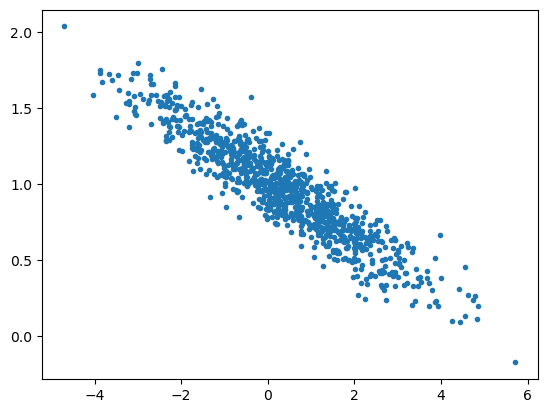

In [4]:
# Dataset and Dataloader with low-rank Gaussian
lowrank_gauss = gmm.LowrankGaussian(n_samples=1000, n_features=2, rank=2)
lowrank_gauss_dataset = lowrank_gauss.generate_data()

plt.plot(lowrank_gauss_dataset[:,0], lowrank_gauss_dataset[:,1], '.')

In [14]:
BATCH_SIZE = 256
INPUT_DIM = 2
EPOCHS = 100

args = {}
args['run_name'] = "Rectified flow"
args['epochs'] = EPOCHS
args['batch_size'] = BATCH_SIZE
args['input_dim'] = INPUT_DIM

args['device'] = device
args['lr'] = 5e-3
args['sample_size'] = 500
args['sigma_blurring'] = np.sqrt(0.1)
args['tiling'] = 'uniform'  # 'uniform' or 'distorted'
args['time_steps'] = 200

#dataset = rf.MyDataset(gmm_knn.data, gmm_knn.labels)
dataset = rf.MyDataset(lowrank_gauss_dataset, [0]*len(lowrank_gauss_dataset)) # all data points have same label
dataloader = rf.DataLoader(dataset, batch_size= args['batch_size'], shuffle=True)
args['dataloader']= dataloader



In [15]:
dataloader
dataloader.dataset[0][0].shape[0]

2

dataloader = args['dataloader']
sample_size = args['sample_size']  # Keep it as an integer, no need to convert to a tensor
sigma_blurring  = args['sigma_blurring']
time_steps = args['time_steps']

model_SB = rf.ScoreNetFourier(input_dim = dataloader.dataset[0][0].shape[0]).to(device)

optimizer_SB = optim.AdamW(model_SB.parameters(), lr=args['lr'])
mse = nn.MSELoss()
rect_flow = rf.rectified_flow(input_dim = args['input_dim'], time_steps = time_steps,
                            tiling = args['tiling'], device=device)
logger = SummaryWriter(os.path.join("runs", args['run_name']))
l = len(dataloader)

loss_SB_curve = []
t = rect_flow.sample_timesteps()  # Timesteps on the same device

# Mini-batch gradient descent
for epoch in range(args['epochs']):
    logging.info(f"Starting epoch {epoch}:")
    pbar = tqdm(dataloader)
    for i, (data, _) in enumerate(pbar):
        print('iteration:', i, 'epoch:', epoch)
        data = data.to(torch.float32)
        data = data.to(device)  # Ensure images are on the device
        
        
        x_t, _ = rect_flow.noise_images(data, t)  # Ensure these tensors are on the correct device
        t_expanded = t.view(len(t), 1, 1).expand(len(t), data.shape[0], 1)
        

        # Blurred score formulation
        predict_SB = model_SB(x_t[:-1, :, :], t_expanded[:-1]) # to avoid score estimation t = 1
        SB = rf.score_blurred(x_t, data, t, sigma_blurring) # does not give the score at t=1
        print('SB.shape, predict_SB.shape', SB.shape, predict_SB.shape)
        loss_SB = mse(SB, predict_SB) 

        optimizer_SB.zero_grad()
        loss_SB.backward()
        optimizer_SB.step()


        
        

        
        loss_SB_curve.append(loss_SB.item())

        pbar.set_postfix( MSE_SB = loss_SB.item())
        logger.add_scalar("MSE_SB", loss_SB.item(), global_step=epoch * l + i)

In [16]:
SB[10].max(),predict_SB.max()

NameError: name 'SB' is not defined

In [17]:
examples, init_samples, loss_curve, traj = rf.train(args, device)

#examples_SB, init_samples_SB, loss_curve_SB, traj_SB = rf.train_SB(args, device)

{'run_name': 'Rectified flow', 'epochs': 100, 'batch_size': 256, 'input_dim': 2, 'device': device(type='cpu'), 'lr': 0.005, 'sample_size': 500, 'sigma_blurring': 0.31622776601683794, 'tiling': 'uniform', 'time_steps': 200, 'dataloader': <torch.utils.data.dataloader.DataLoader object at 0x16b52c7d0>}


  0%|          | 0/4 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([201, 256, 2])) that is different to the input size (torch.Size([256, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
 25%|██▌       | 1/4 [00:00<00:00,  7.53it/s, MSE=2.97]

iteration: 0 epoch: 0
x_t.shape, t_expanded.shape torch.Size([201, 256, 2]) torch.Size([201, 256, 1])
iteration: 1 epoch: 0
x_t.shape, t_expanded.shape torch.Size([201, 256, 2]) torch.Size([201, 256, 1])


 25%|██▌       | 1/4 [00:00<00:00,  7.53it/s, MSE=2.06]

iteration: 2 epoch: 0
x_t.shape, t_expanded.shape torch.Size([201, 256, 2]) torch.Size([201, 256, 1])


...

  0%|          | 0/4 [00:00<?, ?it/s, MSE=1.55]

iteration: 1 epoch: 99
x_t.shape, t_expanded.shape torch.Size([201, 256, 2]) torch.Size([201, 256, 1])


 75%|███████▌  | 3/4 [00:00<00:00, 22.89it/s, MSE=1.43]

iteration: 2 epoch: 99
x_t.shape, t_expanded.shape torch.Size([201, 256, 2]) torch.Size([201, 256, 1])
iteration: 3 epoch: 99
x_t.shape, t_expanded.shape torch.Size([201, 232, 2]) torch.Size([201, 232, 1])


100%|██████████| 199/199 [00:00<00:00, 3874.76it/s]


/var/folders/vn/wcs2tz697rb3rf5l0rfkyr4w0000gn/T/ipykernel_35252/2222298534.py:12: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


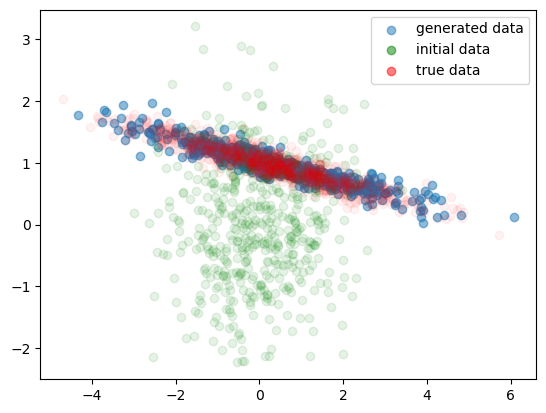

In [18]:
#W2_rect = rf.emd2_multivariate(gmm_knn.data, np.array(examples))
plt.scatter(examples[:,0], examples[:,1], label = 'generated data', alpha = 0.5)
plt.scatter(init_samples[:,0], init_samples[:,1], label = 'initial data', color = 'green', alpha = 0.1)
#plt.scatter(gmm_knn.data[:,0], gmm_knn.data[:,1], color = 'red', alpha = 0.05, label = 'true data')
plt.scatter(lowrank_gauss_dataset[:,0], lowrank_gauss_dataset[:,1], color = 'red', alpha = 0.05, label = 'true data')
#plt.scatter(traj[:,200,0], traj[:,200,1], color = 'orange', alpha = 0.05)
# n in range(args['sample_size']):
#    plt.scatter(traj[:,n,0], traj[:,n,1], color = 'orange', alpha = 0.05, s = 1e-3)

legend = plt.legend()
# Set the alpha only in the legend box
for handle in legend.legendHandles:
    handle.set_alpha(0.5)  # Adjust this alpha value as desired




In [ ]:
# torch.var(init_samples)
# torch.mean(init_samples)
torch.var(examples), torch.mean(examples)

(tensor(46.5338), tensor(-0.0748))

In [ ]:
traj[1,200,:], examples[200,:]

(tensor([1.4182, 0.5427]), tensor([ 5.2054, -4.9013]))

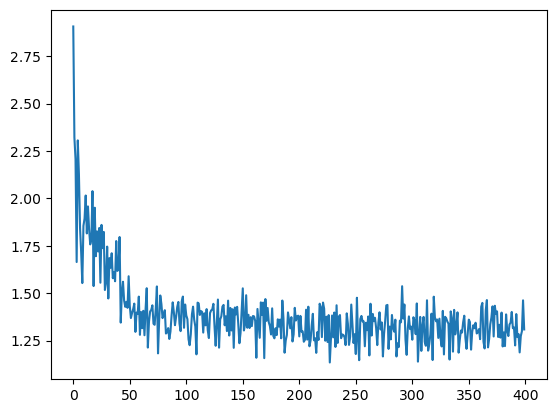

In [10]:
plt.plot(loss_curve)

In [11]:


labels = np.arange(0, N_CLUSTERS)
data = gmm_knn.data
sample_dict = []
for label in labels:
    idx = np.where(gmm_knn.labels == label)[0]
    X_label = data[idx, :]
    print('cluster size:', X_label.shape[0])
    args1 = {}
    args1['run_name'] = "Rectified flow"
    args1['epochs'] = EPOCHS
    args1['batch_size'] = BATCH_SIZE
    args1['input_dim'] = INPUT_DIM

    args1['device'] = device
    args1['lr'] = 5 * 1e-5
    args1['sample_size'] = int(500 * gmm_knn.calculate_proportions()[label])



    dataset1 = rf.MyDataset(X_label, [label]*X_label.shape[0])
    dataloader1 = rf.DataLoader(dataset1, batch_size= args['batch_size'], shuffle=True)
    args1['dataloader']= dataloader1

    examples1, _ = rf.train(args1, device)

    if label == 0: sample_dict = examples1
    else: sample_dict = np.vstack((sample_dict, examples1))

cluster size: 333
Cluster Proportions:
Cluster 1: 33.33%
Cluster 2: 33.33%
Cluster 0: 33.33%
{'run_name': 'Rectified flow', 'epochs': 100, 'batch_size': 256, 'input_dim': 2, 'device': device(type='cpu'), 'lr': 5e-05, 'sample_size': 166, 'dataloader': <torch.utils.data.dataloader.DataLoader object at 0x16a5ae3c0>}


KeyError: 'time_steps'

/var/folders/vn/wcs2tz697rb3rf5l0rfkyr4w0000gn/T/ipykernel_45868/2615007935.py:9: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend1.legendHandles:
/var/folders/vn/wcs2tz697rb3rf5l0rfkyr4w0000gn/T/ipykernel_45868/2615007935.py:18: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend2.legendHandles:


Text(0.5, 1.0, 'Vanilla RF, $W_2=$1.12')

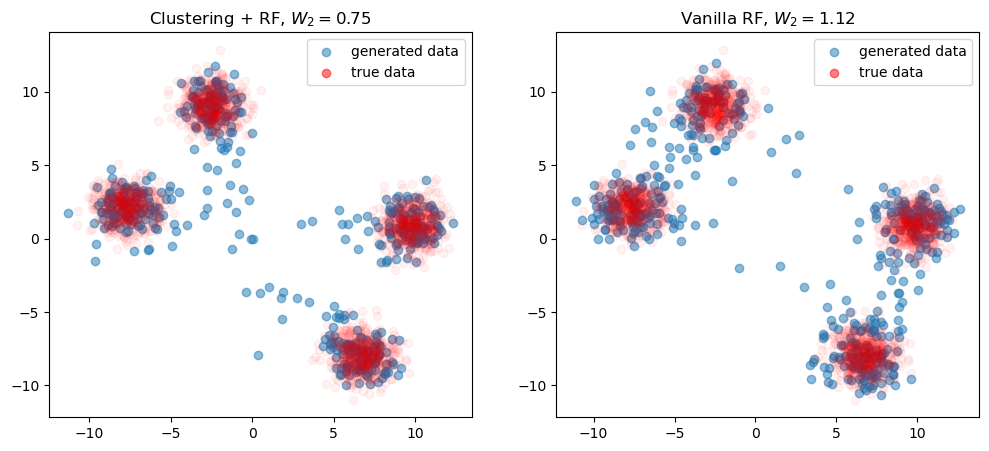

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


W2_clustrect = rf.emd2_multivariate(gmm_knn.data, sample_dict)
ax1.scatter(sample_dict[:,0], sample_dict[:,1], label = 'generated data', alpha = 0.5)
ax1.scatter(gmm_knn.data[:,0], gmm_knn.data[:,1], color = 'red', alpha = 0.05, label = 'true data')
legend1 = ax1.legend()
# Set the alpha only in the legend box
for handle in legend1.legendHandles:
    handle.set_alpha(0.5)  # Adjust this alpha value as desired
ax1.set_title(f'Clustering + RF, $W_2=${W2_clustrect:.2f}')

W2_rect = rf.emd2_multivariate(gmm_knn.data, np.array(examples))
ax2.scatter(examples[:,0], examples[:,1], label = 'generated data', alpha = 0.5)
ax2.scatter(gmm_knn.data[:,0], gmm_knn.data[:,1], color = 'red', alpha = 0.05, label = 'true data')
legend2 = ax2.legend()
# Set the alpha only in the legend box
for handle in legend2.legendHandles:
    handle.set_alpha(0.5)  # Adjust this alpha value as desired

ax1.set_title(f'Clustering + RF, $W_2=${W2_clustrect:.2f}')
ax2.set_title(f'Vanilla RF, $W_2=${W2_rect:.2f}')

In [ ]:
W2_clustrect, W2_rect

(0.5702472103575463, 1.2329314738154846)

tensor([[-0.0202, -0.1746,  1.0953,  ...,  1.3077, -1.4285, -2.1356],
        [ 0.3183,  0.8853,  0.2714,  ...,  0.5212,  0.5908, -0.7984],
        [ 1.2820, -0.5170,  0.2330,  ...,  0.1244,  0.8301,  0.1631],
        ...,
        [-0.0987, -0.4830, -0.2378,  ...,  1.1502, -0.1439,  1.7177],
        [ 0.7355,  0.3817,  0.4329,  ..., -0.5386, -0.4001,  0.8291],
        [-0.6760,  0.5439,  0.0299,  ...,  1.0083, -0.5162, -0.8338]])

0.5000000000000001

In [ ]:
tensors = []
for i in range(5):
    # Create a 2D tensor of shape (2, 3) for example
    tensor = torch.tensor([[i, i+1, i+2], [i+3, i+4, i+5]])
    tensors.append(tensor)

# Stack tensors along a new dimension (e.g., dimension 0)
stacked_tensor = torch.stack(tensors)
print("Stacked Tensor (torch.stack):\n", stacked_tensor)
print("Shape:", stacked_tensor.shape)

Stacked Tensor (torch.stack):
 tensor([[[0, 1, 2],
         [3, 4, 5]],

        [[1, 2, 3],
         [4, 5, 6]],

        [[2, 3, 4],
         [5, 6, 7]],

        [[3, 4, 5],
         [6, 7, 8]],

        [[4, 5, 6],
         [7, 8, 9]]])
Shape: torch.Size([5, 2, 3])


In [ ]:
x = torch.randint(0,5, (5,3)) 
t = torch.rand(4)

x1 = t[ None, :, None] + x[:, None, :]
x1.shape



torch.Size([5, 4, 3])

In [ ]:
#x2 = []
x2.append(x.detach().clone())
x2_torch = torch.stack(x2)
x2_torch.shape

torch.Size([4, 5, 3])

In [ ]:
x = torch.rand(5, 3, 2) * 10
#print(x)
x[0][None, :,:].shape

torch.Size([1, 3, 2])

In [ ]:
torch.linspace(0, 1, 100)

tensor([0.0000, 0.0101, 0.0202, 0.0303, 0.0404, 0.0505, 0.0606, 0.0707, 0.0808,
        0.0909, 0.1010, 0.1111, 0.1212, 0.1313, 0.1414, 0.1515, 0.1616, 0.1717,
        0.1818, 0.1919, 0.2020, 0.2121, 0.2222, 0.2323, 0.2424, 0.2525, 0.2626,
        0.2727, 0.2828, 0.2929, 0.3030, 0.3131, 0.3232, 0.3333, 0.3434, 0.3535,
        0.3636, 0.3737, 0.3838, 0.3939, 0.4040, 0.4141, 0.4242, 0.4343, 0.4444,
        0.4545, 0.4646, 0.4747, 0.4848, 0.4949, 0.5051, 0.5152, 0.5253, 0.5354,
        0.5455, 0.5556, 0.5657, 0.5758, 0.5859, 0.5960, 0.6061, 0.6162, 0.6263,
        0.6364, 0.6465, 0.6566, 0.6667, 0.6768, 0.6869, 0.6970, 0.7071, 0.7172,
        0.7273, 0.7374, 0.7475, 0.7576, 0.7677, 0.7778, 0.7879, 0.7980, 0.8081,
        0.8182, 0.8283, 0.8384, 0.8485, 0.8586, 0.8687, 0.8788, 0.8889, 0.8990,
        0.9091, 0.9192, 0.9293, 0.9394, 0.9495, 0.9596, 0.9697, 0.9798, 0.9899,
        1.0000])